## DynBet QuickStart

DynBet 是一个**动态下注模拟框架**

只需定义游戏 (Game) 输赢规则并组合策略 (Strategy) 

框架维护余额 (Vault) 与对局历史 (Session)

### 1. 定义游戏

SimpleGame 是一个简单的实现, 从列表轮询获取结果, True 表示赢, False 表示输

In [1039]:
from game import Game


class SimpleGame(Game):
    def __init__(self, seq: list[bool]):
        self.seq = seq
        self.index = 0

    def once(self, bet: float) -> float | None:
        won = self.seq[self.index % len(self.seq)]
        self.index += 1
        if won:
            # 赢了,双倍返还
            return bet * 2
        # 输了, 啥也没有 (None)


game = SimpleGame([True])  # 一直赢

### 2. 进行游戏

`Vault` 持有余额与初始下注额

`Session` 管理游戏与余额, 每 `run` 一次就进行一局

In [1040]:
from session import Session
from vault import Vault
from strategy import Strategy

vault = Vault(1000.0, 10.0)  # 初始余额为 1000, 每局游戏初始下注 10
session = Session(game, vault)  # 创建会话
print(vault.money)  # 1000.0
session.run(Strategy())  # 以空策略运行一次
print(vault.money)  # 1010.0

1000.0
1010.0


### 3. 游戏策略

策略是一个管道: `Strategy().apply(A).apply(B)` 会依次执行 A 和 B

下面的 `Echo` 是我们调试用的妙妙工具, 它包裹任意策略并把**实际下注额**打印出来, 方便观察

In [1041]:
from data import Data


class Echo(Strategy):
    def __init__(self, strategy: Strategy, f: str = "-> %.2f\n"):
        super().__init__()
        self.strategy = strategy
        self.format = f

    def apply(self, strategy: Strategy) -> Strategy:
        self.strategy.apply(strategy)
        return self

    def bet(self, vault: Vault, data: Data) -> Vault:
        bet = self.strategy.bet(vault, data)
        print(self.format % bet.withdrawal, end="")
        return bet

#### 3.1 基础策略

最朴素的几种策略: 平注、按比例、全仓、随机

In [1042]:
from strategy import Flat

# 平注
session.run(Echo(Flat(20.0)))  # 下注 20 (覆盖初始下注)
print(vault.money)  # 1030.0

-> 20.00
1030.0


In [1043]:
from strategy import Ratio

# 按比例下注
session.run(Echo(Ratio(0.5)))  # 下注初始下注的 50%
print(vault.money)  # 1035.0

-> 5.00
1035.0


In [1044]:
from strategy import Allin

# 全仓下注
session.run(Echo(Allin()))  # 下注所有资金
print(vault.money)  # 2070.0

-> 1035.00
2070.0


In [1045]:
from strategy import Random

# 在余额范围内随机下注
previous = vault.money
bet = session.run(Echo(Random()))
print(vault.money)

vault.money = 1000.0  # 重置余额

-> 387.04
2457.0373769277703


#### 3.2 组合策略

用 `apply` 把多个策略串成管道

前面的策略修改下注额, 后面的策略在它的基础上继续作用

In [1046]:
strategy = Strategy()  # 创建空策略
strategy.apply(Echo(Flat(100.0)))  # 平注 100
strategy.apply(Echo(Ratio(0.5)))  # 缩放 50%
session.run(strategy)
print(vault.money)  # 1050.0

-> 100.00
-> 50.00
1050.0


错误用法: 所有基础策略都不会执行 apply 在它之上的策略

In [1047]:
session.run(Echo(Flat(100.0)).apply(Echo(Ratio(0.5))))  # 下注额 100 不会变成 50
print(vault.money)  # 1150.0

-> 100.00
1150.0


通过组合策略, 可以实现许多复杂的策略

例如下注余额的 10%

In [1048]:
strategy = Strategy().apply(Echo(Allin())).apply(Echo(Ratio(0.1)))
session.run(strategy)
print(vault.money)  # 1265.0

-> 1150.00
-> 115.00
1265.0


#### 3.3 分支聚合策略

`Aggregator` (`Max`, `Min`, `Sum`) 会**同时**跑管道里的所有子策略, 再按规则聚合

子策略各自拿到余额快照, 互不影响

In [1049]:
from strategy import Max, Min, Sum


def apply(target: Strategy):
    # 应用三个平注子策略
    target.apply(Echo(Flat(10.0), "Sub 1 -> %.2f\n"))
    target.apply(Echo(Flat(20.0), "Sub 2 -> %.2f\n"))
    target.apply(Echo(Flat(30.0), "Sub 3 -> %.2f\n"))
    return target

取最大下注额

In [1050]:
strategy = apply(Echo(Max(), "Max -> %.2f\n"))  #
session.run(strategy)
print(vault.money)  # 1295.0

Sub 1 -> 10.00
Sub 2 -> 20.00
Sub 3 -> 30.00
Max -> 30.00
1295.0


取最小下注额

In [1051]:
strategy = apply(Echo(Min(), "Min -> %.2f\n"))
session.run(strategy)
print(vault.money)  # 1305.0

Sub 1 -> 10.00
Sub 2 -> 20.00
Sub 3 -> 30.00
Min -> 10.00
1305.0


Sum -> Ratio 取平均下注额

In [1052]:
strategy = Strategy().apply(apply(Sum())).apply(Ratio(1 / 3))
strategy = Echo(strategy, "Average -> %.2f\n")
session.run(strategy)
print(vault.money)  # 1325.0

Sub 1 -> 10.00
Sub 2 -> 20.00
Sub 3 -> 30.00
Average -> 20.00
1325.0


#### 3.4 分支选择策略

`Fork` 在主策略和管道之间二选一: 条件成立执行主策略, 否则依次执行管道里的策略

In [1053]:
from strategy import Fork

strategy1 = Strategy()
strategy2 = Strategy()
strategy3 = Strategy()
# 基类: 条件成立则执行 strategy1, 否则依次执行 strategy2 -> strategy3 -> ...
fork = Fork(strategy1).apply(strategy2).apply(strategy3)

公平硬币游戏: 赢则翻倍返还, 输则归零

In [1054]:
import random


class Coin(Game):
    def once(self, bet: float) -> float | None:
        return bet * 2 if random.randint(0, 1) else None

##### 3.4.1 普通分支选择策略

`Peak` 在**当前余额处于历史最高点**时条件成立

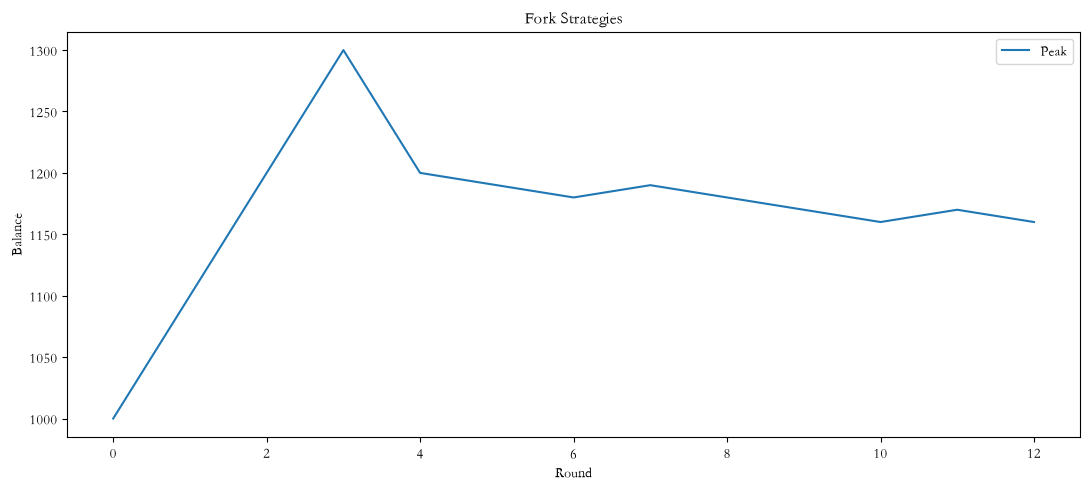

In [1055]:
from visualize import Visualizer
from strategy import Peak

game = Coin()
vault = Vault(1000.0, 10.0)
session = Session(game, vault)

# 当余额处于历史最高点时重仓下注 100, 否则保守平注 10
strategy = Peak(Flat(100.0)).apply(Flat(10.0))
for _ in range(12):
    session.run(strategy)

viz = Visualizer("Fork Strategies", "Round", "Balance")


def money(session: Session):
    return [n.vault.money for n in session.data.nodes]


viz.add(money(session), "Peak").show()

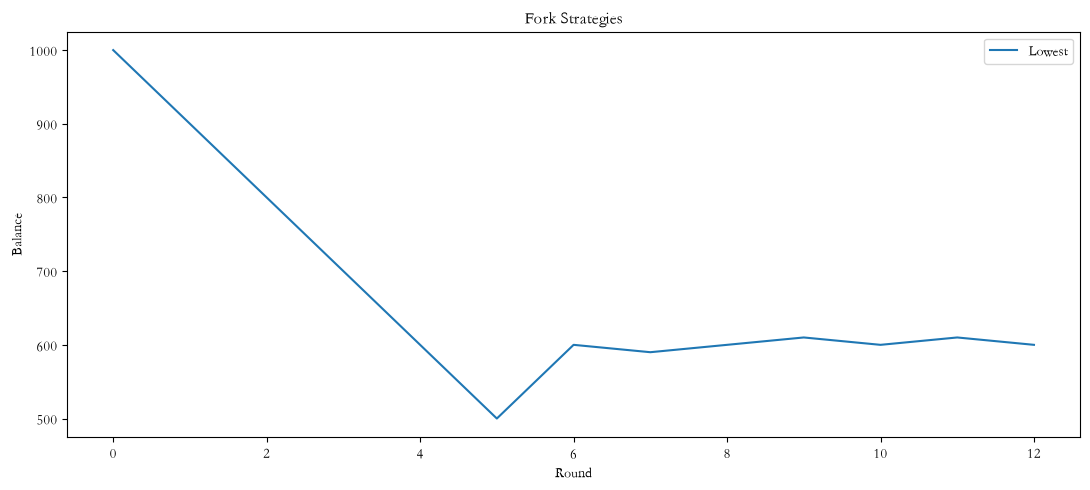

In [1056]:
from strategy import Lowest

# 反过来: 处于历史最低点时重仓博反弹
vault = Vault(1000.0, 10.0)
session = Session(game, vault)

strategy = Lowest(Flat(100.0)).apply(Flat(10.0))
for _ in range(12):
    session.run(strategy)

viz.clear()
viz.add(money(session), "Lowest").show()

##### 3.4.2 锁定策略 (Lock)

`Lock` 会先**试算**其内部策略的下注额并存储相应额度, 后续依赖余额的计算会扣掉存储部分

它的条件永远不成立, 管道必定触发


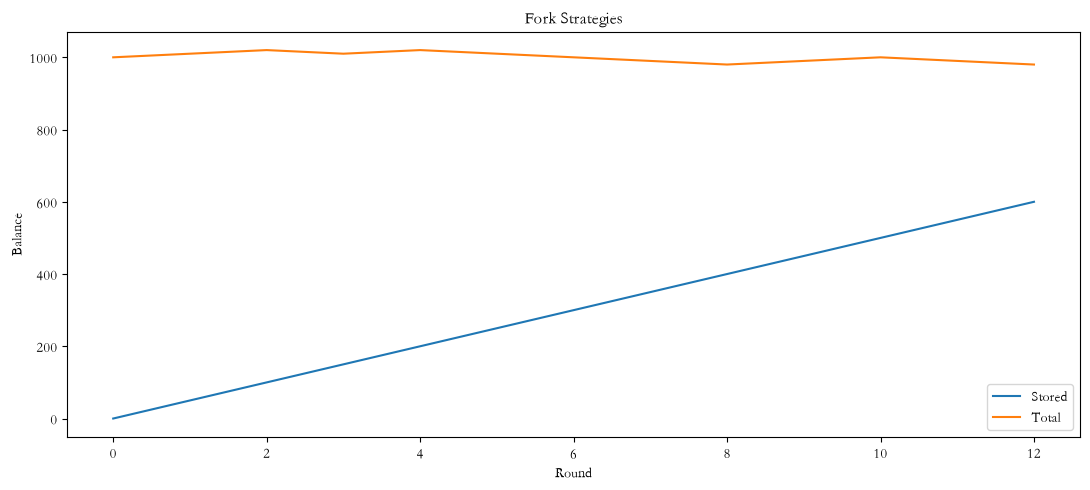

In [1057]:
from strategy import Lock

vault = Vault(1000.0, 10.0)
session = Session(game, vault)
# 每局先锁定 50, 再平注 10
strategy = Lock(Flat(50.0)).apply(Flat(10.0))

for _ in range(12):
    session.run(strategy)


def total(session: Session):
    return [node.vault.total for node in session.data.nodes]


def stored(session: Session):
    return [node.vault.stored for node in session.data.nodes]


viz.clear()
viz.add(stored(session), "Stored").add(total(session), "Total").show()

#### 3.5 渐进式策略 (Progressive)

`Progressive` 是一族**根据历史输赢动态调整下注额**的策略

下面用确定性的 `SimpleGame` 把每种策略的下注额变化摆出来看清楚

In [1058]:
from strategy import Martingale, DAlembert, Fibonacci, Labouchere, Stepping


def execute(strategy, seq):
    g = SimpleGame(seq)
    v = Vault(1000.0, 10.0)
    s = Session(g, v)
    for _ in range(len(seq)):
        s.run(strategy)
    return s


viz = Visualizer("Progressive", "Round", "Balance")

马丁格尔: 输了翻倍, 赢了复位

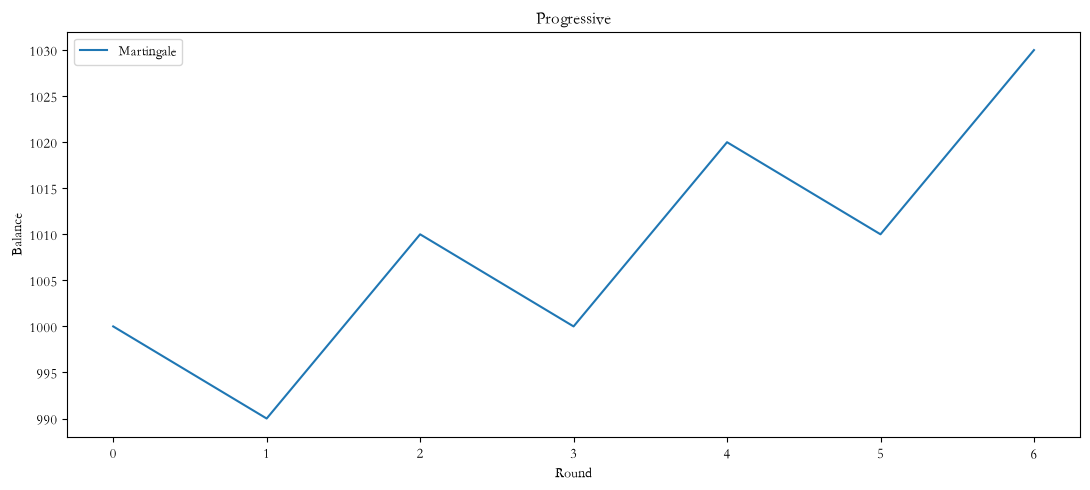

In [1059]:
session = execute(Martingale(), [False, True, False, True, False, True])
viz.add(money(session), "Martingale").show()

达朗贝尔: 输了 +1 单位, 赢了 -1 单位

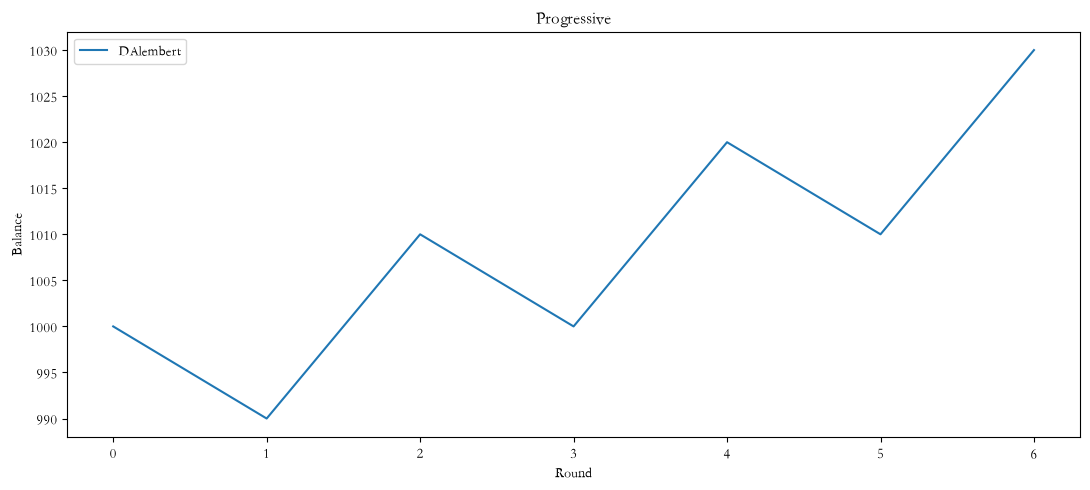

In [1060]:
session = execute(DAlembert(), [False, True, False, True, False, True])
viz.clear()
viz.add(money(session), "DAlembert").show()

斐波那契: 赢了沿斐波那契数列前进, 输了回退两步

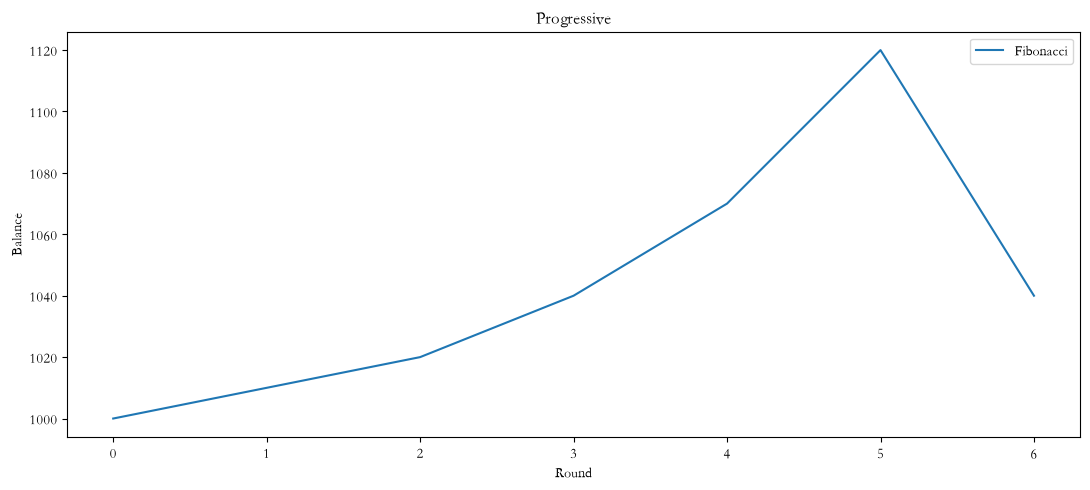

In [1061]:
session = execute(Fibonacci(), [True, True, True, True, True, False])
viz.clear()
viz.add(money(session), "Fibonacci").show()

阶梯策略: 连赢时按档位递增, 一输即复位

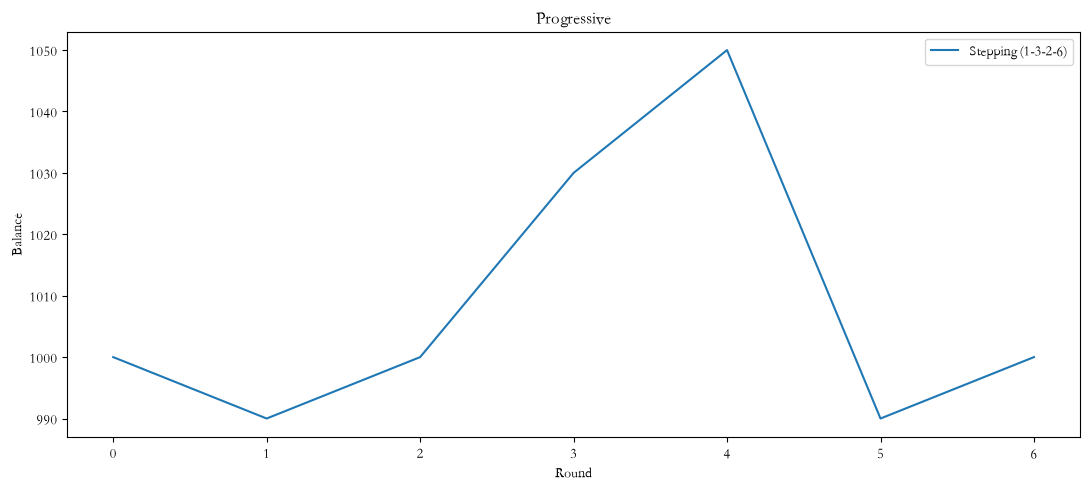

In [1062]:
# 经典的 1-3-2-6 系统
session = execute(Stepping([1, 3, 2, 6]), [False, True, True, True, False, True])
viz.clear()
viz.add(money(session), "Stepping (1-3-2-6)").show()

拉博契尔: 下注管道首尾之和, 赢了划掉下注项, 输了把下注项之和加入管道末尾

只有一项时直接根据该项下注, 管道为空时执行内部策略

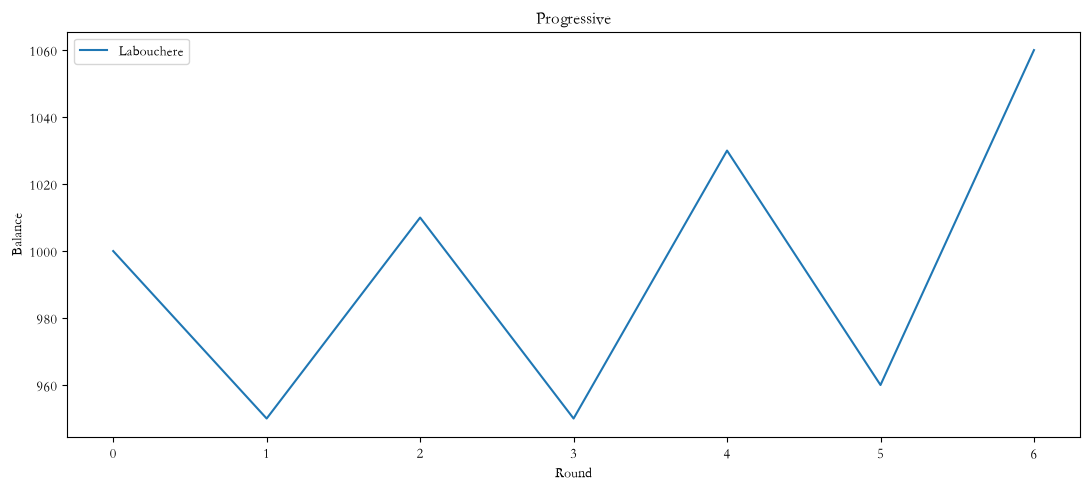

In [1063]:
session = execute(
    Labouchere(Flat(10.0))
    .apply(Flat(10.0))
    .apply(Flat(20.0))
    .apply(Flat(30.0))
    .apply(Flat(40.0)),
    [False, True, False, True, False, True],
)
viz.clear()
viz.add(money(session), "Labouchere").show()

### 4. 大横评

说了这么多, 你也许坐不住了

让我们跑跑实际数据, 来个大横评

#### 4.1 骰子游戏

扔若干个若干面的骰子, 骰子点数全相同则失败, 否则若总和大于期望则获胜, 按倍率返还

In [1064]:
from utils import positive, same
from functools import cached_property

class Dice(Game):
    def __init__(self, dice: list[int], amount: int, rate: float):
        self.dice = dice
        if not positive(self.length, amount, rate):
            raise ValueError
        self.amount = amount
        self.rate = rate

    def once(self, bet: float) -> float | None:
        if self.random():
            return bet * self.rate

    def random(self) -> bool:
        result = [self.roll() for _ in range(self.amount)]
        if same(result):
            return False
        total = sum(result)
        return total >= self.mean

    def roll(self):
        return random.choice(self.dice)

    @property
    def length(self):
        return len(self.dice)

    @cached_property
    def mean(self):
        return (sum(self.dice) * self.amount + self.length - 1) // self.length

以最经典的 Sic Bo 为例, 测测预期

In [1065]:
dice = Dice([i for i in range(1, 7)], 3, 2.0)

win = 0
size = 100000
for _ in range(size):
    win += dice.random()

print(win / size)

0.48471


胜率约为 48.6% , 庄家占优

#### 4.2 策略混战

万轮模拟, 图表统计, 智能结论

Battle: 10000 回合, Vault(10000.0, 10.0), 骰宝大小单双, seed=0.5079879316561485, 胜率 = 48.81%

Flat 10 (Baseline)        | 最终:     7620.0 | 峰值:    10070.0 | 回撤:  24.6% | [亏损]
1% Bankroll               | 最终:      561.3 | 峰值:    10694.6 | 回撤:  94.9% | [亏损]
2% Bankroll               | 最终:       11.6 | 峰值:    11372.5 | 回撤:  99.9% | [亏损]
DAlembert                 | 最终:        0.0 | 峰值:    20090.0 | 回撤: 100.0% | [爆仓]
Rev. DAlembert            | 最终:        0.0 | 峰值:    11450.0 | 回撤: 100.0% | [爆仓]
Martingale                | 最终:        0.0 | 峰值:    18840.0 | 回撤: 100.0% | [爆仓]
Rev. Martingale           | 最终:        0.0 | 峰值:    15650.0 | 回撤: 100.0% | [爆仓]
Fibonacci                 | 最终:        0.0 | 峰值:    10060.0 | 回撤: 100.0% | [爆仓]
1326 System               | 最终:     7100.0 | 峰值:    10960.0 | 回撤:  40.5% | [亏损]
Paroli 1-2-4              | 最终:     5580.0 | 峰值:    10260.0 | 回撤:  45.7% | [亏损]
Labouchere                | 最终:     7840.0 | 峰值:    10290.0 | 回撤:  24.1% | [亏损]
Peak -> 2%, else 1%       | 最终:   

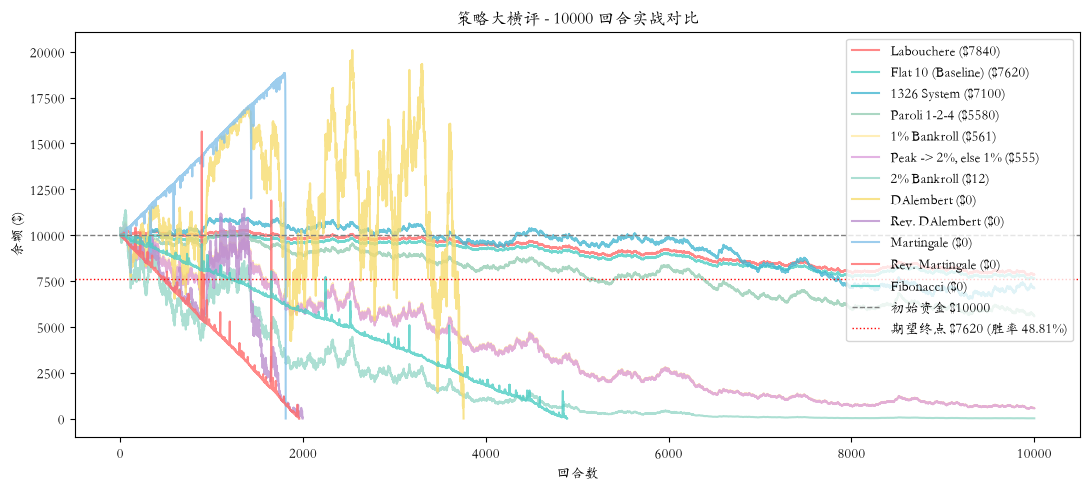

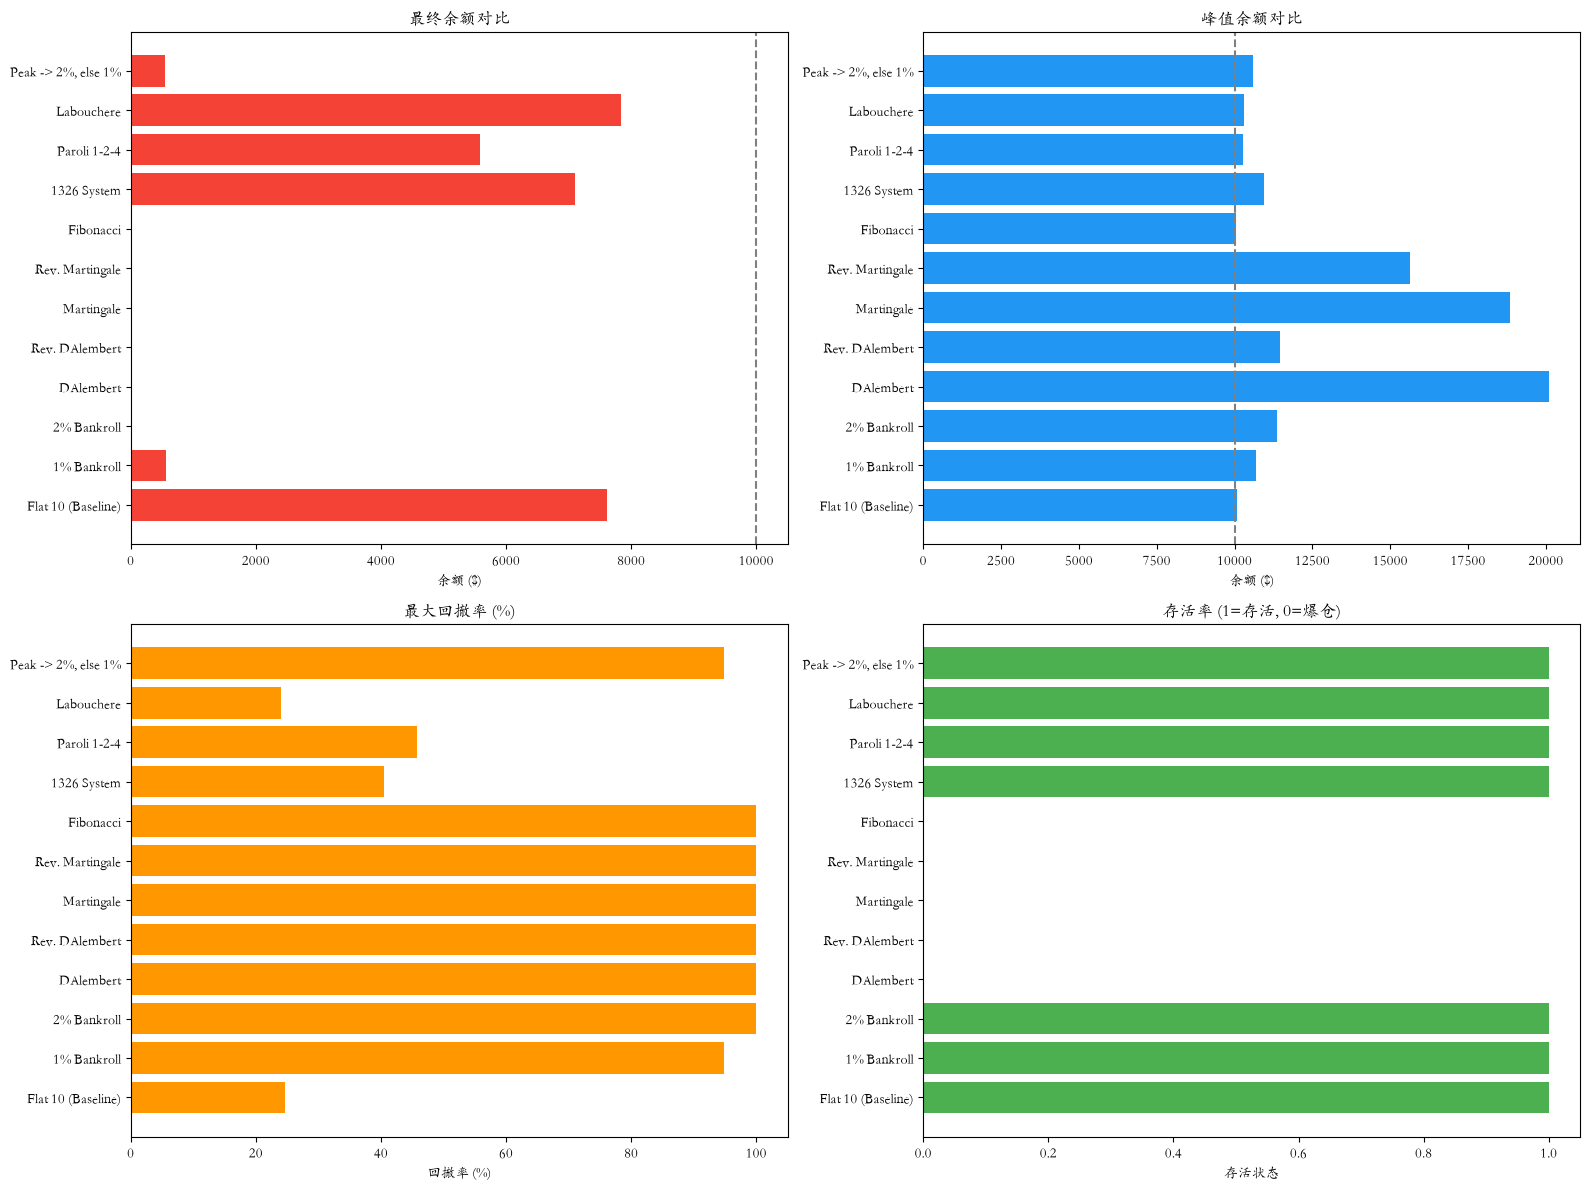


大横评总结报告: 10000 回合, 骰宝大小单双 (胜率 48.81%)

盈利策略 (0/12):

亏损但存活 (7/12):
  1. Labouchere                -21.6%  (最低: $7810, 回撤: 24.1%)
  2. Flat 10 (Baseline)        -23.8%  (最低: $7590, 回撤: 24.6%)
  3. 1326 System               -29.0%  (最低: $6520, 回撤: 40.5%)
  4. Paroli 1-2-4              -44.2%  (最低: $5570, 回撤: 45.7%)
  5. 1% Bankroll               -94.4%  (最低: $546, 回撤: 94.9%)
  6. Peak -> 2%, else 1%       -94.4%  (最低: $540, 回撤: 94.9%)
  7. 2% Bankroll               -99.9%  (最低: $11, 回撤: 99.9%)

爆仓清零 (5/12):
  - DAlembert               血本无归
  - Rev. DAlembert          血本无归
  - Martingale              血本无归
  - Rev. Martingale         血本无归
  - Fibonacci               血本无归

庄边 +2.38%/手。Flat 10 连下 10000 回合，预期盈亏 = $-2380。

洞察分析:
  * 庄家优势 2.38%，长期看数学期望为负，不建议持续高频下注。
  * 胜率 48.81% 接近公平赔率，短期运气能掩盖庄边，但长期必亏。
  * 爆仓率 42% (5/12)，步进策略在负EV下加速破产。
  * 所有「负渐进/序列系统」全部爆仓，马丁格尔类策略请慎用。


In [1066]:
ROUNDS = 10000
INITIAL = 10000.0
SEED = random.random()
dice = Dice([i for i in range(1, 7)], 3, 2.0)


def run(strategy, rounds=ROUNDS, seed=SEED):
    # 每次固定种子保证各策略面对相同骰子序列
    random.seed(seed)
    v = Vault(INITIAL, 10.0)
    # 用 Dice 游戏跑指定轮数
    s = Session(dice, v)
    for _ in range(rounds):
        if v.money <= 0:
            break
        s.run(strategy)
    return s


# 待测策略: 平注 / 比例 / 负渐进 / 正渐进 / 取消系统 / 自适应
strategies = {
    "Flat 10 (Baseline)": Flat(10.0),
    "1% Bankroll": Strategy().apply(Allin()).apply(Ratio(0.01)),
    "2% Bankroll": Strategy().apply(Allin()).apply(Ratio(0.02)),
    "DAlembert": Strategy().apply(Flat(10.0)).apply(DAlembert()),
    "Rev. DAlembert": Strategy().apply(Flat(10.0)).apply(DAlembert(reverse=True)),
    "Martingale": Strategy().apply(Flat(10.0)).apply(Martingale()),
    "Rev. Martingale": Strategy().apply(Flat(10.0)).apply(Martingale(reverse=True)),
    "Fibonacci": Strategy().apply(Flat(10.0)).apply(Fibonacci()),
    "1326 System": Strategy().apply(Flat(10.0)).apply(Stepping([1, 3, 2, 6])),
    "Paroli 1-2-4": Strategy().apply(Flat(10.0)).apply(Stepping([1, 2, 4])),
    "Labouchere": Labouchere(Flat(10.0))
    .apply(Flat(10.0))
    .apply(Flat(20.0))
    .apply(Flat(30.0))
    .apply(Flat(40.0)),
    "Peak -> 2%, else 1%": Peak(Strategy().apply(Allin()).apply(Ratio(0.02))).apply(
        Strategy().apply(Allin()).apply(Ratio(0.01))
    ),
}

random.seed(SEED)
win_count = 0
for _ in range(ROUNDS):
    if dice.random():
        win_count += 1
WIN_RATE = win_count / ROUNDS * 100
BET = 10.0
PAYOUT = 2.0
EXPECTED_FINAL = INITIAL + ROUNDS * BET * (WIN_RATE / 100 * PAYOUT - 1)

print(
    f"Battle: {ROUNDS} 回合, Vault({INITIAL}, {BET}), 骰宝大小单双, seed={SEED}, 胜率 = {WIN_RATE:.2f}%\n"
)
results = {}

for name, strategy in strategies.items():
    try:
        session = run(strategy)
        balances = money(session)
        final = balances[-1]
        peak = max(balances)
        low = min(balances)
        drawdown = (peak - low) / peak * 100 if peak > 0 else 0
        busted = final <= 0

        results[name] = {
            "balances": balances,
            "final": final,
            "peak": peak,
            "min": low,
            "drawdown": drawdown,
            "busted": busted,
        }

        status = "[爆仓]" if busted else ("[盈利]" if final > INITIAL else "[亏损]")
        print(
            f"{name:<25} | 最终: {final:>10.1f} | 峰值: {peak:>10.1f} | 回撤: {drawdown:>5.1f}% | {status}"
        )
    except Exception as e:
        print(f"{name:<25} | [失败] {str(e)[:60]}")
        results[name] = None

# --- 余额曲线 ---
viz = Visualizer(f"策略大横评 - {ROUNDS} 回合实战对比", "回合数", "余额 ($)")

sorted_results = sorted(
    [(n, d) for n, d in results.items() if d],
    key=lambda x: x[1]["final"],
    reverse=True,
)

colors = [
    "#FF6B6B",
    "#4ECDC4",
    "#45B7D1",
    "#96CEB4",
    "#FFEAA7",
    "#DDA0DD",
    "#98D8C8",
    "#F7DC6F",
    "#BB8FCE",
    "#85C1E9",
]

for i, (name, data) in enumerate(sorted_results):
    viz.add(
        data["balances"],
        f"{name} (${data['final']:.0f})",
        color=colors[i % len(colors)],
        alpha=0.8,
    )

viz.hline(INITIAL, f"初始资金 ${INITIAL:.0f}", color="gray", linestyle="--")
viz.hline(
    EXPECTED_FINAL,
    f"期望终点 ${EXPECTED_FINAL:.0f} (胜率 {WIN_RATE:.2f}%)",
    color="red",
    linestyle=":",
).show()

# --- 统计图 ---
import matplotlib.pyplot as plt

valid = {n: d for n, d in results.items() if d}

if valid:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    names = list(valid.keys())
    finals = [valid[n]["final"] for n in names]
    peaks = [valid[n]["peak"] for n in names]
    drawdowns = [valid[n]["drawdown"] for n in names]
    survival = [0 if valid[n]["busted"] else 1 for n in names]

    axes[0, 0].barh(
        names, finals, color=["#4CAF50" if f > INITIAL else "#F44336" for f in finals]
    )
    axes[0, 0].axvline(x=INITIAL, color="gray", linestyle="--", label="初始资金")
    axes[0, 0].set_title("最终余额对比")
    axes[0, 0].set_xlabel("余额 ($)")

    axes[0, 1].barh(names, peaks, color="#2196F3")
    axes[0, 1].axvline(x=INITIAL, color="gray", linestyle="--", label="初始资金")
    axes[0, 1].set_title("峰值余额对比")
    axes[0, 1].set_xlabel("余额 ($)")

    axes[1, 0].barh(names, drawdowns, color="#FF9800")
    axes[1, 0].set_title("最大回撤率 (%)")
    axes[1, 0].set_xlabel("回撤率 (%)")

    axes[1, 1].barh(
        names, survival, color=["#4CAF50" if s else "#F44336" for s in survival]
    )
    axes[1, 1].set_title("存活率 (1=存活, 0=爆仓)")
    axes[1, 1].set_xlabel("存活状态")

    plt.tight_layout()
    plt.show()

# --- 总结报告 ---
print("\n" + "=" * 70)
print(f"大横评总结报告: {ROUNDS} 回合, 骰宝大小单双 (胜率 {WIN_RATE:.2f}%)")
print("=" * 70)

winners = [(n, d) for n, d in results.items() if d and d["final"] > INITIAL]
losers = [(n, d) for n, d in results.items() if d and 0 < d["final"] <= INITIAL]
busted = [(n, d) for n, d in results.items() if d and d["final"] <= 0]

print(f"\n盈利策略 ({len(winners)}/{len(results)}):")
for i, (name, data) in enumerate(
    sorted(winners, key=lambda x: x[1]["final"], reverse=True), 1
):
    pct = (data["final"] - INITIAL) / INITIAL * 100
    print(
        f"  {i}. {name:<23} {pct:>+7.1f}%  (峰值: ${data['peak']:.0f}, 回撤: {data['drawdown']:.1f}%)"
    )

print(f"\n亏损但存活 ({len(losers)}/{len(results)}):")
for i, (name, data) in enumerate(
    sorted(losers, key=lambda x: x[1]["final"], reverse=True), 1
):
    pct = (data["final"] - INITIAL) / INITIAL * 100
    print(
        f"  {i}. {name:<23} {pct:>+7.1f}%  (最低: ${data['min']:.0f}, 回撤: {data['drawdown']:.1f}%)"
    )

if busted:
    print(f"\n爆仓清零 ({len(busted)}/{len(results)}):")
    for name, data in busted:
        print(f"  - {name:<23} 血本无归")

if winners:
    best = max(winners, key=lambda x: x[1]["final"])
    print(f"\n冠军策略: {best[0]}")
    print(
        f"   最终余额: ${best[1]['final']:.2f}  ({(best[1]['final']-INITIAL)/INITIAL*100:+.2f}%)"
    )
    print(f"   峰值余额: ${best[1]['peak']:.2f}  最大回撤: {best[1]['drawdown']:.1f}%")

print("\n" + "=" * 70)
HOUSE_EDGE = (100 - WIN_RATE * PAYOUT) / 100 * 100
EXPECTED_LOSS = ROUNDS * BET * HOUSE_EDGE / 100
print(
    f"庄边 {HOUSE_EDGE:+.2f}%/手。Flat {BET:.0f} 连下 {ROUNDS} 回合，预期盈亏 = ${-EXPECTED_LOSS:+.0f}。"
)

print("\n洞察分析:")

if HOUSE_EDGE > 0:
    print(f"  * 庄家优势 {HOUSE_EDGE:.2f}%，长期看数学期望为负，不建议持续高频下注。")
    if WIN_RATE >= 47 and WIN_RATE <= 50:
        print(
            f"  * 胜率 {WIN_RATE:.2f}% 接近公平赔率，短期运气能掩盖庄边，但长期必亏。"
        )
    elif WIN_RATE < 47:
        print(f"  * 胜率仅 {WIN_RATE:.2f}%，庄边极为明显，远离此类游戏。")
elif HOUSE_EDGE < 0:
    print(f"  * 玩家优势 {-HOUSE_EDGE:.2f}%！数学期望为正，凯利公式最大化长期收益。")
else:
    print(f"  * 庄边≈0，完全公平赌局，比拼的是资金管理和心理素质。")

bust_count = len([d for d in results.values() if d and d["busted"]])
total_valid = len([d for d in results.values() if d])
if bust_count > 0:
    bust_rate = bust_count / total_valid * 100
    print(
        f"  * 爆仓率 {bust_rate:.0f}% ({bust_count}/{total_valid})，步进策略在负EV下加速破产。"
    )

winners_any = [(n, d) for n, d in results.items() if d and d["final"] > INITIAL]
if winners_any:
    avg_dd = sum(d["drawdown"] for _, d in winners_any) / len(winners_any)
    if avg_dd > 50:
        print(f"  * 盈利策略平均回撤 {avg_dd:.0f}%，大起大落，心理素质要求极高。")
    elif avg_dd > 20:
        print(f"  * 盈利策略平均回撤 {avg_dd:.0f}%，波动可控，但仍需风控。")
    else:
        print(f"  * 盈利策略平均回撤仅 {avg_dd:.0f}%，这条策略曲线非常稳健。")

proportional_names = ["Bankroll", "Ratio"]
step_names = [
    "Martingale",
    "DAlembert",
    "Fibonacci",
    "Labouchere",
    "Stepping",
    "1326",
    "Paroli",
]
flat_names = ["Flat", "Baseline"]
busted_set = {n for n, d in results.items() if d and d["busted"]}

if any(any(k in n for k in step_names) for n in busted_set):
    print("  * 所有「负渐进/序列系统」全部爆仓，马丁格尔类策略请慎用。")
elif winners:
    winner_name = best[0]
    if any(k in winner_name for k in proportional_names):
        print(f"  * 冠军「{winner_name}」是比例下注，负EV下比例下注是最优风控。")
    elif any(k in winner_name for k in flat_names):
        print(f"  * 冠军「{winner_name}」是平注，简单就是美，其他花式都是徒增方差。")
    elif any(k in winner_name for k in step_names):
        print(f"  * 冠军「{winner_name}」是步进系统，此轮运气占主要成分，不可复制。")
    else:
        print(f"  * 冠军「{winner_name}」，混合策略展现了组合优势。")

print("=" * 70)